# Formality

- Work together in groups of four people. Sign up for a group in Studium.

- The exercise is examinated by oral examination during the exercise session 4 OR by handing in a
written report with the group’s answers to the questions in Studium. Name your report 
**Lab3_LastName1_LastName2_LastName3** . If you choose your work to be evaluated during
exercise session 4, make sure all the group members are present and prepare a report with the main
results to simplify the evaluation, otherwise, you will be asked to submit a full report on Studium.

First, we load the grayscale image coins.tif using OpenCV. This image contains several coins (dark circular objects) on a light background. Some coins have bright details (highlights) on them, and a few coins touch or overlap each other.

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

I = cv2.imread('lab3/images/coins.tif', cv2.IMREAD_GRAYSCALE)

plt.imshow(I, cmap='gray')
plt.axis('off')            # Hide axis ticks
plt.show()

# Assignment

Counting objects is a fairly common problem in image analysis. Often the segmentation is difficult, due to non-uniform illumination, shadows, blur, reflections 
etc. The problems here are that some objects are slightly overlapping or partiall 
hidden (but still possible to identify). Some of the objects also contain bright pixe s
that should be counted as part of the object. Those difficulties must be taken i to
consideration when solving the assignm

The report should contain:
1. Your script that solves the task. Include a comment for every function sayin 
why that particular function was needed.
2. An image showing the final segmentation resulIONS
3. A histogram showing the distribution of object size. Either area or  adius
could be used as a size measure (see figure).
4. A discussion of errors and limitations in your final method.
5. As you can see, the objects are coins. Is it possible to count the tot l amount
of money using your algorithm?
6. Explain how your method treat the coins on the image border.
7. Is your solution general in the sense that it can be used when analyzing images with arbitrary circular objects (i.e. not only coins.tif)? Try it on
bacteria.tif. Does it work on arbitrary ellipsoid or co vex objects?
Describe some possible modifications you could make to your program.
ent.

And here is an example of a histogram that would show the distribution of coins found in an image:
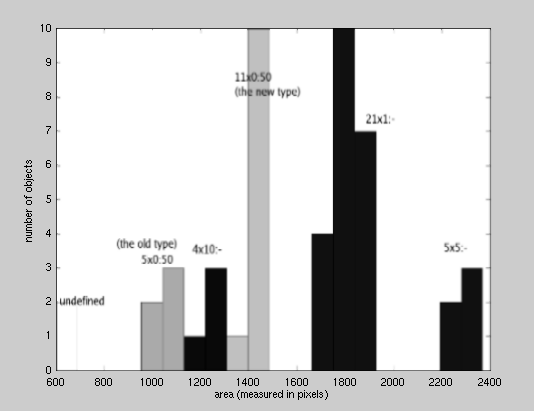

Below are some Python functions (from OpenCV, scikit-image, numpy, and matplotlib) that will be useful for this lab. Check the documentation for details and examples. Not all of these are required to solve the task, but understanding them will help.

* Thresholding and Binary Masks
`cv2.threshold(I, T, 255, cv2.THRESH_BINARY)`
Threshold the grayscale image I at intensity level T (0 ≤ T ≤ 255) to create a binary image.
Returns (ret, binary) where binary is a mask image with 0 or 255 values.

`threshold_otsu(I)` (from skimage.filters)
Automatically computes an optimal global threshold (Otsu’s method) based on the image histogram.

`binary = I < T` (using NumPy)
Simple boolean thresholding, producing a binary mask (True/False).

* Histograms and Visualization
`plt.hist(I.ravel(), bins=256)` (from matplotlib)
Plots the intensity histogram of a grayscale image.

`plt.imshow(I, cmap='gray')`
Displays a grayscale or binary image.

* Distance Transform
`cv2.distanceTransform(binary, cv2.DIST_L2, 5)`
Computes the distance transform of a binary mask using Euclidean distance (or cv2.DIST_L1 for cityblock).
Result is a float image where each pixel’s value is the distance to the nearest background pixel.

* Watershed Segmentation
`watershed(-dist, markers, mask=binary)` (from skimage.segmentation)
Performs watershed segmentation. Typically applied to the negative distance transform using labeled markers.
mask restricts watershed to foreground regions.

* Logical Operations
`np.logical_and(A, B), np.logical_or(A, B), np.logical_xor(A, B), np.logical_not(A)`
Pixel-wise logical operations between binary images.

* Labeling and Region Properties
`label(binary, connectivity=2)` (from skimage.measure)
Labels connected components in a binary image. connectivity=2 for 8-connectivity in 2D.

`label2rgb(labels, image=I)` (from skimage.color)
Converts a labeled segmentation to a color overlay for visualization.

`regionprops(labels)` (from skimage.measure)
Extracts features from labeled regions.

* Local Maxima Detection
`peak_local_max(dist, min_distance=1)` (from skimage.feature)
Finds local maxima in an image (e.g., peaks in distance transform). Returns coordinates or a boolean mask.
Can be used to find object centers for marker-based segmentation.

* Filtering
`cv2.medianBlur(I, ksize=3)`
Applies a median filter to reduce noise or fill small holes (e.g., coin engravings).

`cv2.filter2D(I, -1, kernel)`
Applies a custom 2D filter (e.g., mean filter kernel).

`gaussian(I, sigma) (from skimage.filters)`
Smooths the image using a Gaussian filter.

Morphological Operations
`cv2.morphologyEx(I, cv2.MORPH_OPEN, kernel)`
Morphological opening (erosion followed by dilation).

`cv2.morphologyEx(I, cv2.MORPH_CLOSE, kernel)`
Morphological closing (dilation followed by erosion).

`cv2.erode(I, kernel), cv2.dilate(I, kernel)`
Basic erosion and dilation operations.

`disk(radius)` (from skimage.morphology)
Creates a circular structuring element for morphological operations.

* Other Potentially Useful Tools
`remove_small_objects(binary, min_size)` (from skimage.morphology)
Removes connected components smaller than min_size pixels (useful for cleaning noise).

`binary_closing, binary_opening` (from skimage.morphology)
Higher-level morphological operations to close small gaps or remove small protrusions.

`skeletonize(binary)` (from skimage.morphology)
Reduces objects to their skeleton representation.

#### Solution

In [ ]:
# imports
from matplotlib import pyplot as plt
from skimage import filters, morphology, measure, color, segmentation, feature

# find threshold and plt
T = filters.threshold_otsu(I)

I = cv2.medianBlur(I, ksize=3) # remove highlights from coins

binary  = I < T

plt.imshow(binary, cmap='gray')
plt.axis('off')            # Hide axis ticks
plt.show()

plt.hist(I.ravel(), bins=256)
plt.show()



In [ ]:
dist0 = cv2.distanceTransform(binary.astype(np.uint8), cv2.DIST_L2, 0)
distcityblock0 = cv2.distanceTransform(binary.astype(np.uint8), cv2.DIST_L1, 0)

dist3 = cv2.distanceTransform(binary.astype(np.uint8), cv2.DIST_L2, 3)
distcityblock3 = cv2.distanceTransform(binary.astype(np.uint8), cv2.DIST_L1, 3)

dist5 = cv2.distanceTransform(binary.astype(np.uint8), cv2.DIST_L2, 5)
distcityblock5 = cv2.distanceTransform(binary.astype(np.uint8), cv2.DIST_L1, 5)

plt.figure(figsize=(12, 8))
plt.subplot(2,3,1), plt.imshow(dist0, cmap='gray'), plt.title('L2 0')
plt.subplot(2,3,2), plt.imshow(dist3, cmap='gray'), plt.title('L2 3')
plt.subplot(2,3,3), plt.imshow(dist5, cmap='gray'), plt.title('L2 5')
plt.subplot(2,3,4), plt.imshow(distcityblock0, cmap='gray'), plt.title('L1(Cityblock) 0')
plt.subplot(2,3,5), plt.imshow(distcityblock3, cmap='gray'), plt.title('L1(Cityblock) 3')
plt.subplot(2,3,6), plt.imshow(distcityblock5, cmap='gray'), plt.title('L1(Cityblock) 5')
plt.show()

# simmilar results for each configuration

In [ ]:
coords = feature.peak_local_max(
    dist5,
    footprint=np.ones((3, 3)),
    labels=binary
)

markers = np.zeros(dist5.shape, dtype=int)

for i, (r, c) in enumerate(coords, start=1):
    markers[r, c] = i

markers.shape == dist5.shape

labels = segmentation.watershed(
    -dist5,
    markers,
    mask=binary
)

plt.imshow(labels)
plt.axis('off')            # Hide axis ticks
plt.show()


In [ ]:
L = measure.label(binary, connectivity=2)

plt.imshow(color.label2rgb(L, bg_label=0)) 
plt.axis('off')            # Hide axis ticks
plt.show()

In [ ]:
# IM = cv2.morphologyEx(binary.astype(np.uint8), cv2.MORPH_OPEN, kernel=cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3)))

# IM = morphology.opening(binary, morphology.disk(15))

#kernel = np.ones((5,5),np.uint8)
# IM = cv2.erode(binary.astype(np.uint8),kernel,iterations = 4)

IM = morphology.disk(10)

plt.figure(figsize=(6,6))
plt.subplot(1,2,1)
plt.imshow(binary, cmap='gray')
plt.axis('off')            # Hide axis ticks
plt.title('Before Morph')

plt.subplot(1,2,2)
plt.imshow(IM, cmap='gray')
plt.axis('off')            # Hide axis ticks
plt.title('After Morph')
plt.show()

In [ ]:
def show(img, title, cmap='gray'):
    plt.figure(figsize=(5,5))
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis('off')
    plt.show()

In [ ]:
I = cv2.imread('lab3/images/coins.tif', cv2.IMREAD_GRAYSCALE)
show(I, "Original image")

############    median filter     ############
I_filtered = cv2.medianBlur(I, ksize=5) # remove highlights from coins 
show(I_filtered, "After median filtering")
############     ############       ############


############    binary as uint8     ############
# find optimal threshold and create binary image white bg black coins
T = filters.threshold_otsu(I_filtered)
binary = I_filtered < T
binary = binary.astype(np.uint8) *255
show(binary, "Binary image")
############     ############       ############

# did not seem necessary
############    morphological close     ############
# close small gaps in the coins to get better segmentation
#kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
#binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
#show(binary, "After morphological closing")
############     ############       ############


############    erode   ############
# Shrink the coins a bit to separate touching coins
selem = morphology.disk(4) # above 4 is too much
binary_eroded = cv2.erode(binary, selem)

show(binary_eroded, "After erosion (separating touching coins)")
############     ############       ############


############    dist   ############
# find center of coins (nearest to background)
dist = cv2.distanceTransform(binary_eroded, cv2.DIST_L2, 5)

show(dist, "Distance transform")
############     ############       ############

# local max's one per coin
coords = feature.peak_local_max(
    dist,
    min_distance=10,
    labels=binary_eroded
)

# convert coords to markers because watershed does not take list of points (i.e coords)
# resize to image shape
markers = np.zeros(dist.shape, dtype=int)
for i, (r, c) in enumerate(coords, start=1):
    markers[r, c] = i

labels = segmentation.watershed(
    -dist,
    markers,
    mask=binary
)

In [ ]:
plt.figure(figsize=(6,6))
plt.imshow(labels, cmap='nipy_spectral')
plt.title("Watershed segmentation (one color per circle)")
plt.axis('off')
plt.show()

num_circles = len(np.unique(labels)) - 1
print("Number of circles:", num_circles)

areas = [region.area for region in measure.regionprops(labels)]
plt.figure(figsize=(6,4))
plt.hist(areas, bins=20, edgecolor='black')
plt.xlabel("Area (pixels)")
plt.ylabel("Number of objects")
plt.title("Distribution of object areas")
plt.show()


print("Expected number of circles: 48 seen below:")
counted_image = cv2.imread('lab3/images/image.png')
plt.imshow(counted_image)
plt.axis('off')            # Hide axis ticks
plt.show()

#### Bacteria.tif

In [ ]:

IB = cv2.imread('lab3/images/bacteria.tif', cv2.IMREAD_GRAYSCALE)

show(IB, "Original Bacteria Image")

In [ ]:



############    median filter     ############
I_filtered = cv2.medianBlur(IB, ksize=5) # remove highlights from coins 
show(I_filtered, "After median filtering")
############     ############       ############


############    binary as uint8     ############
# find optimal threshold and create binary image white bg black coins
T = filters.threshold_otsu(I_filtered)
binary = I_filtered < T
binary = binary.astype(np.uint8) *255
show(binary, "Binary image")
############     ############       ############

# did not seem necessary
############    morphological close     ############
# close small gaps in the coins to get better segmentation
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
show(binary, "After morphological closing")
############     ############       ############


############    erode   ############
# Shrink the coins a bit to separate touching coins
selem = morphology.disk(4) # above 4 is too much
binary_eroded = cv2.erode(binary, selem)

show(binary_eroded, "After erosion (separating touching coins)")
############     ############       ############


############    dist   ############
# find center of coins (nearest to background)
dist = cv2.distanceTransform(binary_eroded, cv2.DIST_L2, 5)

show(dist, "Distance transform")
############     ############       ############

# local max's one per coin
coords = feature.peak_local_max(
    dist,
    min_distance=10,
    labels=binary_eroded
)

# convert coords to markers because watershed does not take list of points (i.e coords)
# resize to image shape
markers = np.zeros(dist.shape, dtype=int)
for i, (r, c) in enumerate(coords, start=1):
    markers[r, c] = i

labels = segmentation.watershed(
    -dist,
    markers,
    mask=binary
)

In [ ]:
plt.figure(figsize=(6,6))
plt.imshow(labels, cmap='nipy_spectral')
plt.title("Watershed segmentation (one color per circle)")
plt.axis('off')
plt.show()

num_circles = len(np.unique(labels)) - 1
print("Number of circles:", num_circles)

areas = [region.area for region in measure.regionprops(labels)]
plt.figure(figsize=(6,4))
plt.hist(areas, bins=20, edgecolor='black')
plt.xlabel("Area (pixels)")
plt.ylabel("Number of objects")
plt.title("Distribution of object areas")
plt.show()

**A** 

## Reason
The reason this fails is that bacteria can have 2 centers, becasue they can be penut shaped. Peanut-shaped bacteria contain multiple distance-transform maxima, so watershed places multiple seeds and splits one bacterium into two.

# Possible Solution
Reduce or suppress multiple seeds per object (e.g. stronger peak suppression), or switch to a shape-aware method that favors elongated objects instead of watershed.
